# 🚕 Chicago Taxi Trip Analysis

Exploratory data analysis of Chicago taxi activity using **Python**, **Pandas**, **Matplotlib**, and statistical hypothesis testing.

The analysis examines taxi-company activity, the most common drop-off neighborhoods, and whether trip duration from the Loop to O'Hare International Airport differs under adverse weather conditions on Saturdays.


## 1. Setup and data loading

The three datasets are loaded from the repository `data/` directory. They contain taxi-company trip counts, average drop-off activity by neighborhood, and Loop-to-O'Hare trip records with weather conditions.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as st
from pathlib import Path

BASE = Path('..')
DATA = BASE / 'data'

company_df = pd.read_csv(DATA / 'moved_project_sql_result_01.csv')
neighborhood_df = pd.read_csv(DATA / 'moved_project_sql_result_04.csv')
rides = pd.read_csv(DATA / 'moved_project_sql_result_07.csv')

print('Taxi companies:', company_df.shape)
print('Neighborhoods:', neighborhood_df.shape)
print('Airport rides:', rides.shape)


Taxi companies: (64, 2)
Neighborhoods: (94, 2)
Airport rides: (1068, 3)


## 2. Data inspection and quality checks

The datasets are inspected for structure, data types, missing values, and duplicate rows. The timestamp column is converted to a datetime type before the hypothesis test.


In [2]:
for name, df in {
    'company_df': company_df,
    'neighborhood_df': neighborhood_df,
    'rides': rides
}.items():
    print(f'\n{name}')
    print(df.head())
    print('\nData types:')
    print(df.dtypes)
    print('\nMissing values:')
    print(df.isna().sum())
    print('Duplicate rows:', df.duplicated().sum())

rides['start_ts'] = pd.to_datetime(rides['start_ts'])



company_df
                      company_name  trips_amount
0                        Flash Cab         19558
1        Taxi Affiliation Services         11422
2                 Medallion Leasin         10367
3                       Yellow Cab          9888
4  Taxi Affiliation Service Yellow          9299

Data types:
company_name    object
trips_amount     int64
dtype: object

Missing values:
company_name    0
trips_amount    0
dtype: int64
Duplicate rows: 0

neighborhood_df
  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000

Data types:
dropoff_location_name     object
average_trips            float64
dtype: object

Missing values:
dropoff_location_name    0
average_trips            0
dtype: int64
Duplicate rows: 0

rides
              start_ts weather_conditions  duration_seconds
0  2017-11-25 16:00:00  

The company and neighborhood datasets contain no missing values or duplicate rows. The airport-trip dataset contains repeated rows; because identical trip attributes can legitimately occur for different rides and there is no unique trip identifier in this extract, these rows are retained rather than removed automatically.


## 3. Top destination neighborhoods


In [3]:
top10_neighborhoods = (
    neighborhood_df
    .sort_values('average_trips', ascending=False)
    .head(10)
)
top10_neighborhoods


,dropoff_location_name,average_trips
0,Loop,10727.466667
1,River North,9523.666667
2,Streeterville,6664.666667
3,West Loop,5163.666667
4,O'Hare,2546.900000
5,Lake View,2420.966667
6,Grant Park,2068.533333
7,Museum Campus,1510.000000
8,Gold Coast,1364.233333
9,Sheffield & DePaul,1259.766667


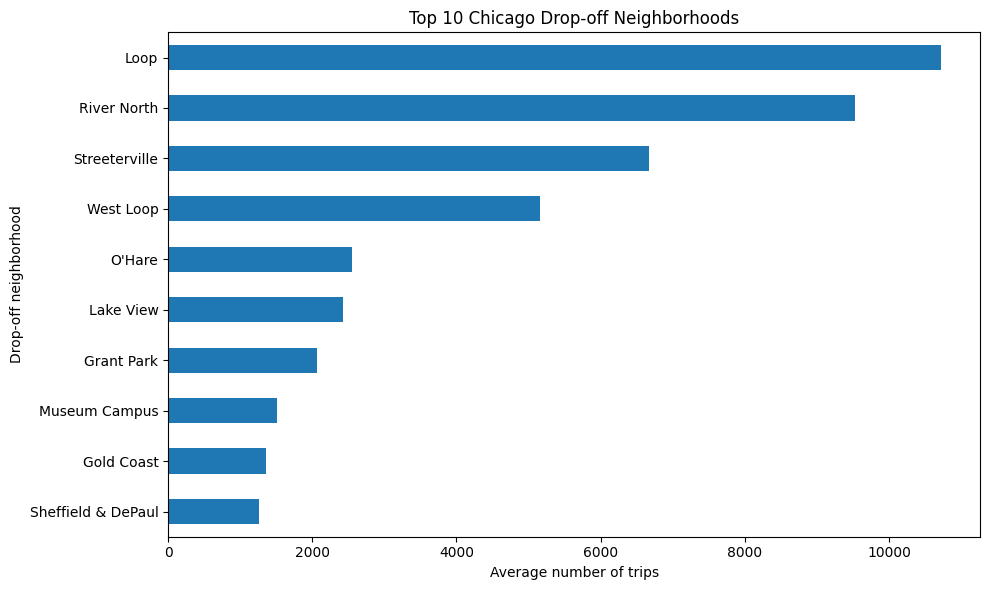

In [4]:
ax = top10_neighborhoods.sort_values('average_trips').plot(
    x='dropoff_location_name',
    y='average_trips',
    kind='barh',
    figsize=(10, 6),
    legend=False
)
ax.set_title('Top 10 Chicago Drop-off Neighborhoods')
ax.set_xlabel('Average number of trips')
ax.set_ylabel('Drop-off neighborhood')
plt.tight_layout()
plt.show()


The destination ranking shows that taxi drop-offs are concentrated in a relatively small number of neighborhoods. This concentration can help identify areas with consistently high passenger demand.


## 4. Taxi company activity


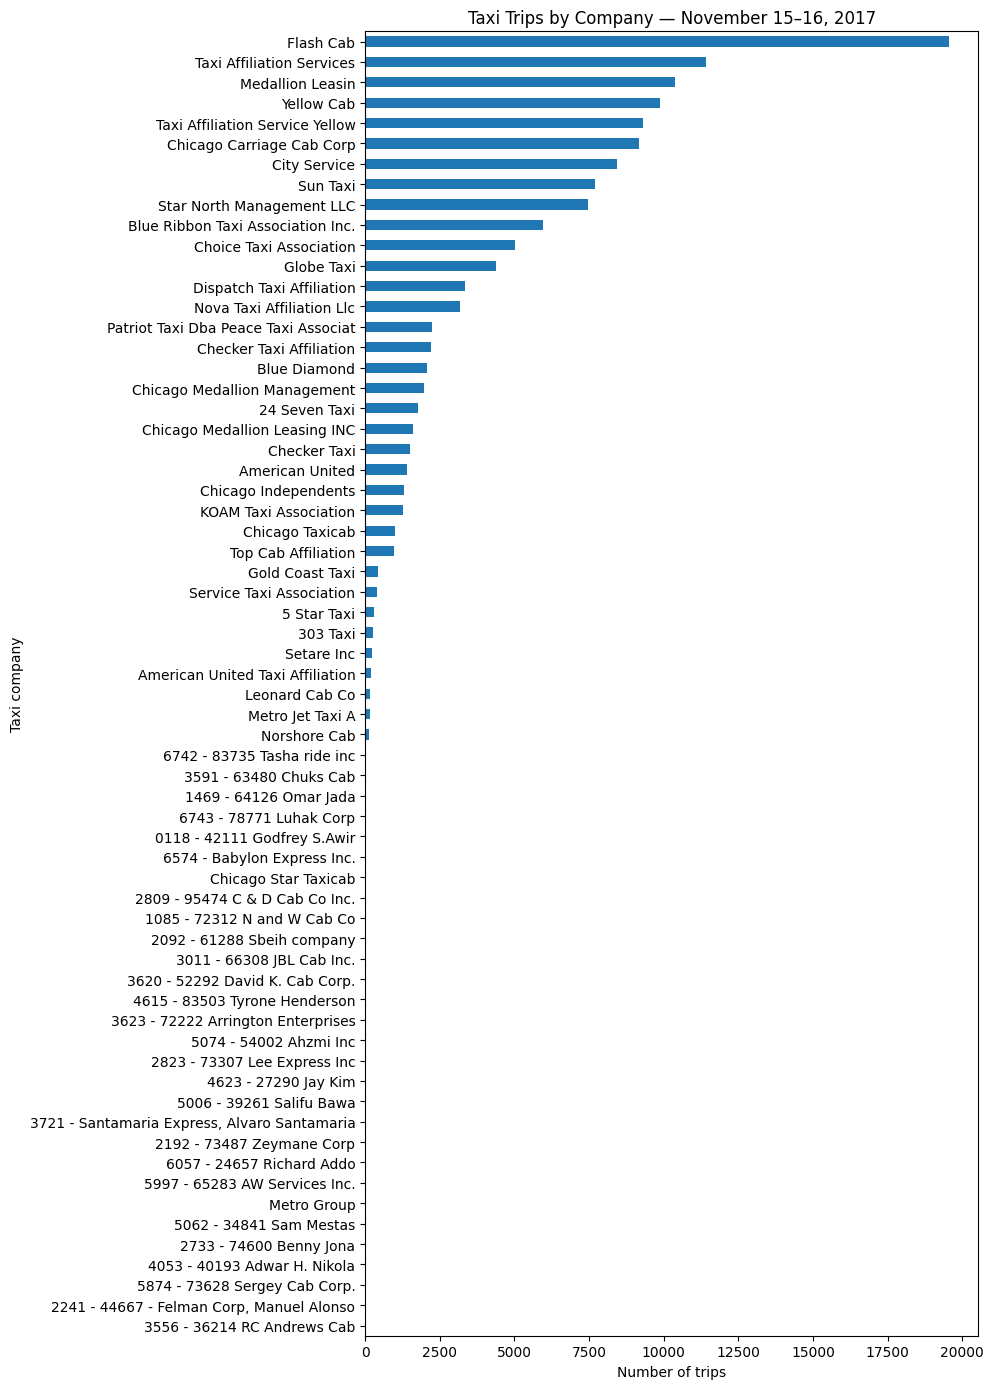

In [5]:
company_sorted = company_df.sort_values('trips_amount', ascending=False)

ax = company_sorted.sort_values('trips_amount').plot(
    x='company_name',
    y='trips_amount',
    kind='barh',
    figsize=(10, 14),
    legend=False
)
ax.set_title('Taxi Trips by Company — November 15–16, 2017')
ax.set_xlabel('Number of trips')
ax.set_ylabel('Taxi company')
plt.tight_layout()
plt.show()


The company distribution is highly uneven: a small group of operators accounts for substantially more trips than the rest of the market. Flash Cab is the most active company in this extract, indicating a strong concentration of trip volume among leading operators.


## 5. Statistical hypothesis test

### Question
Does the average duration of Saturday trips from the Loop to O'Hare International Airport change under adverse weather conditions?

**Null hypothesis (H₀):** the mean trip duration is the same under `Good` and `Bad` weather conditions.

**Alternative hypothesis (H₁):** the mean trip duration differs between `Good` and `Bad` weather conditions.

A significance level of **α = 0.05** is used. Because the two weather groups are independent and equal population variances should not be assumed, Welch's two-sample t-test is applied (`equal_var=False`).


In [6]:
good = rides.loc[
    rides['weather_conditions'] == 'Good',
    'duration_seconds'
].dropna()

bad = rides.loc[
    rides['weather_conditions'] == 'Bad',
    'duration_seconds'
].dropna()

print(f'Good weather: n={len(good)}, mean={good.mean():.2f} seconds')
print(f'Bad weather:  n={len(bad)}, mean={bad.mean():.2f} seconds')

alpha = 0.05
result = st.ttest_ind(good, bad, equal_var=False)

print(f't-statistic: {result.statistic:.4f}')
print(f'p-value: {result.pvalue:.4e}')

if result.pvalue < alpha:
    print('Reject H0: the data provide evidence of a difference in mean trip duration.')
else:
    print('Fail to reject H0: the data do not provide sufficient evidence of a difference.')


Good weather: n=888, mean=1999.68 seconds
Bad weather:  n=180, mean=2427.21 seconds
t-statistic: -7.1860
p-value: 6.7390e-12
Reject H0: the data provide evidence of a difference in mean trip duration.


The test produces a p-value far below 0.05, so the null hypothesis is rejected for this dataset. Average trip duration is higher in the `Bad` weather group than in the `Good` weather group. This is a statistical association in the available sample and does not by itself establish that weather is the sole cause of the difference.


## 6. Key findings

- Taxi activity is concentrated among a relatively small number of companies.
- Drop-off demand is also concentrated in a limited set of Chicago neighborhoods.
- The analyzed Saturday Loop-to-O'Hare trips are longer on average in the `Bad` weather group.
- Welch's t-test indicates that the difference in mean duration between the weather groups is statistically significant at the 5% level.

## 7. Business implications

These patterns can support operational planning by highlighting high-demand destinations, identifying the market's most active taxi operators, and showing that adverse-weather periods may require additional travel-time allowances for airport trips.

## 8. Limitations

The analysis is based on the supplied historical extracts and is descriptive except for the specified hypothesis test. The data do not include every possible factor affecting trip duration, such as detailed traffic conditions, route choice, or trip-level identifiers. Statistical significance should therefore not be interpreted as proof of causality.

## 9. Skills demonstrated

**Python · Pandas · Data Cleaning · Exploratory Data Analysis · Data Visualization · Statistical Hypothesis Testing · Welch's t-test**
